In [ ]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Heartbeat/set_b'
file_list = os.listdir(file_path)

In [ ]:
datake = 11
file = os.listdir(file_path)[datake]
wav_file = wave.open(os.path.join(file_path, file), 'rb')

num_channels = wav_file.getnchannels()
sample_width = wav_file.getsampwidth()
frame_rate = wav_file.getframerate()  #Sample rate (samples per second)
num_frames = wav_file.getnframes()
duration = num_frames / float(frame_rate)  #dalam seconds

print(f"Channels: {num_channels}")
print(f"Sample Width: {sample_width} bytes")
print(f"Frame Rate: {frame_rate} Hz")
print(f"Number of Frames: {num_frames}")
print(f"Duration: {duration:.2f} seconds")

print(file)

Channels: 1
Sample Width: 2 bytes
Frame Rate: 4000 Hz
Number of Frames: 51468
Duration: 12.87 seconds
Bunlabelledtest__109_1305653646620_B.wav


Audio Array: [-150  119  455 ...  823  576   64]
Array Shape: (51468,)


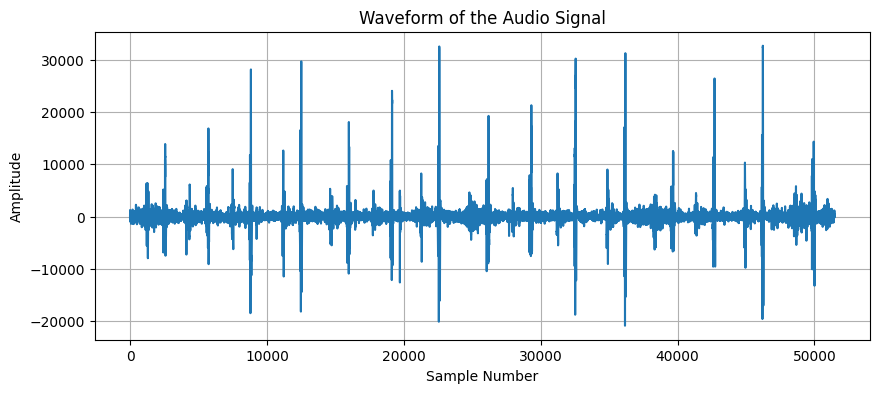

In [ ]:
frames = wav_file.readframes(num_frames)
wav_file.close()

audio_data = np.frombuffer(frames, dtype=np.int16)

if num_channels > 1:
    audio_data = np.reshape(audio_data, (-1, num_channels))

print("Audio Array:", audio_data)
print("Array Shape:", audio_data.shape)

plt.figure(figsize=(10, 4))
if num_channels > 1:
    plt.plot(audio_data[:, 0])
else:
    plt.plot(audio_data)
plt.title('Waveform of the Audio Signal')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

In [ ]:
!pip install sounddevice -qq

In [ ]:
from IPython.display import Audio
audio_to_play = audio_data[:, 0] if num_channels > 1 else audio_data

Audio(audio_to_play, rate=frame_rate)

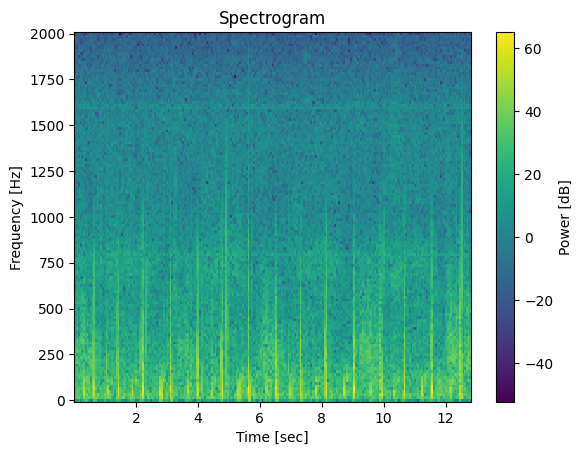

In [ ]:
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(audio_data[:,0] if num_channels > 1 else audio_data, frame_rate)
plt.pcolormesh(t, f, 10 * np.log10(Sxx))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram')
plt.colorbar(label='Power [dB]')
plt.show()

clustering heartbeat

Kmeans & kmeans++

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
file_path = "/content/drive/MyDrive/Heartbeat/set_b/Bunlabelledtest__109_1305653646620_B.wav"

Prepo

In [ ]:
# Load audio
y, sr = librosa.load(file_path, sr=4000)

# Normalisasi amplitudo
y = y / np.max(np.abs(y))

# Bandpass filter (20–200 Hz)
sos = sg.butter(10, [20, 200], btype='bandpass', fs=sr, output='sos')
y = sg.sosfilt(sos, y)

# Ekstraksi MFCC
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
mfcc = mfcc.T   # shape: (n_frames, n_mfcc)

# Normalisasi fitur
scaler = StandardScaler()
mfcc_scaled = scaler.fit_transform(mfcc)

PCA 2D

In [ ]:
pca = PCA(n_components=2)
mfcc_pca = pca.fit_transform(mfcc_scaled)

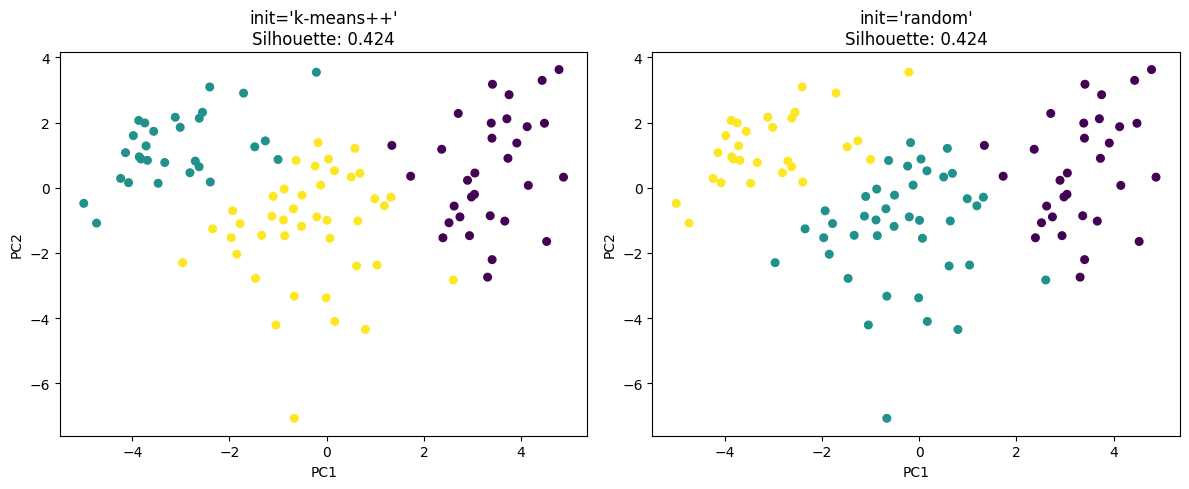

In [ ]:
# 3. Clustering dengan KMeans
# =====================
methods = ["k-means++", "random"]
results = {}

plt.figure(figsize=(12, 5))
for i, m in enumerate(methods):
    kmeans = KMeans(
        n_clusters=3,
        init=m,
        n_init=20,
        random_state=42
    )
    labels = kmeans.fit_predict(mfcc_pca)
    sil = silhouette_score(mfcc_pca, labels)
    results[m] = sil

    ax = plt.subplot(1, len(methods), i+1)
    sc = ax.scatter(mfcc_pca[:,0], mfcc_pca[:,1], c=labels, cmap="viridis", s=30)
    ax.set_title(f"init='{m}'\nSilhouette: {sil:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [ ]:
for m, s in results.items():
    print(f"init = {m:9s}  -> Silhouette Score = {s:.4f}")

init = k-means++  -> Silhouette Score = 0.4240
init = random     -> Silhouette Score = 0.4240


DBscan

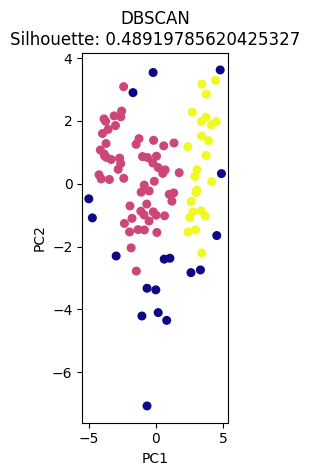

<Figure size 1400x1200 with 0 Axes>

DBSCAN -> Silhouette Score = 0.48919785620425327


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

db = DBSCAN(eps=1.0, min_samples=5).fit(mfcc_pca)
labels_db = db.labels_

unique_labels = set(labels_db)
# Abaikan noise (-1) kalau ada
if len(unique_labels - {-1}) > 1:
    mask = labels_db != -1
    sil_db = silhouette_score(mfcc_pca[mask], labels_db[mask])
else:
    sil_db = None

ax = plt.subplot(1, len(methods)+1, len(methods)+1)
ax.scatter(mfcc_pca[:,0], mfcc_pca[:,1], c=labels_db, cmap="plasma", s=30)
ax.set_title(f"DBSCAN\nSilhouette: {sil_db if sil_db else 'N/A'}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

print(f"DBSCAN -> Silhouette Score = {sil_db if sil_db else 'Tidak bisa dihitung'}")